In [23]:
import roboticstoolbox as rtb
import spatialmath as sm
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# TODO: Fill in the correct parameters from the UR website

link1 = rtb.RevoluteDH(d=0.15185, a=0.0, alpha=np.pi/2)
link2 = rtb.RevoluteDH(d=0.0, a=-0.24355, alpha=0.0)
link3 = rtb.RevoluteDH(d=0.0, a=-0.2132, alpha=0.0)
link4 = rtb.RevoluteDH(d=0.13105, a=0.0, alpha=np.pi/2)
link5 = rtb.RevoluteDH(d=0.08535, a=0.0, alpha=-np.pi/2)
link6 = rtb.RevoluteDH(d=0.0921, a=0.0, alpha=0.0)
# Create the robot object
my_ur3e = rtb.DHRobot([link1, link2, link3, link4, link5, link6], name="My_UR3e")

print(my_ur3e)

DHRobot: My_UR3e, 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │  0.1519 │       0 │  90.0° │
│  q2 │       0 │ -0.2435 │   0.0° │
│  q3 │       0 │ -0.2132 │   0.0° │
│  q4 │   0.131 │       0 │  90.0° │
│  q5 │ 0.08535 │       0 │ -90.0° │
│  q6 │  0.0921 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘



In [25]:
# 1. Define Start and End joint configurations
q_start = np.array([0] * 6)           # Robot straight out
q_end   = np.array([4*np.pi] * 6) # Robot folded 90 degrees

# 2. Generate trajectory (50 steps)
traj = rtb.jtraj(q_start, q_end, 50)

# traj.q contains the 50x2 array of joint angles for the path
print("Shape of trajectory:", traj.q.shape)

# 3. Visualize the movement
# This will animate the robot moving through the path
# my_ur3e.plot(traj.q, backend='pyplot')

Shape of trajectory: (50, 6)


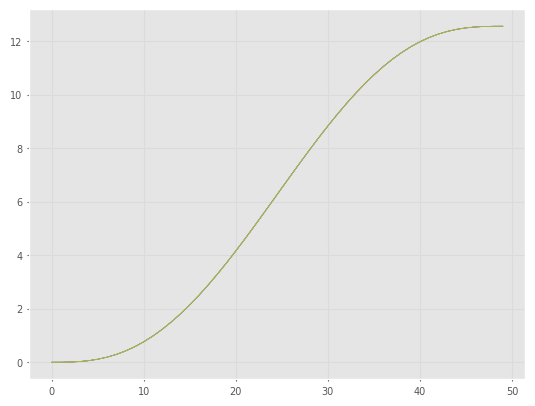

In [26]:
plt.plot(traj.q[:, :])

In [48]:
class KinematicModel:
    def __init__(self, movement_fidelity : int = 50):
        self.time = 0.0 # All time measured in seconds
        self.current_joint_angles = [0] * 6
        self.movement_fidelity = movement_fidelity

        # Inputs
        self.commanded_joint_angles = [0] * 6

        # Movement variables
        self.current_movement_start_angles = [0] * 6
        self.current_movement_start_time = 0.0 # s
        self.current_movement_duration = 0.0 # s

        # Experiment variables
        self.start_time = 0.0
        self.stop_time = 0.0

        # Setup provided kinematic model
        link1 = rtb.RevoluteDH(d=0.15185, a=0.0, alpha=np.pi/2)
        link2 = rtb.RevoluteDH(d=0.0, a=-0.24355, alpha=0.0)
        link3 = rtb.RevoluteDH(d=0.0, a=-0.2132, alpha=0.0)
        link4 = rtb.RevoluteDH(d=0.13105, a=0.0, alpha=np.pi/2)
        link5 = rtb.RevoluteDH(d=0.08535, a=0.0, alpha=-np.pi/2)
        link6 = rtb.RevoluteDH(d=0.0921, a=0.0, alpha=0.0)
        # Create the robot object
        self.robot = rtb.DHRobot([link1, link2, link3, link4, link5, link6], name="robot")

    def _determine_movement_duration(self, start_angles: list, end_angles: list) -> float:
        # Calculate angle difference
        max_angle_diff = np.max(np.abs(np.array(start_angles) - np.array(end_angles)))
        
        # Refer to train_movement_time_model.ipynb to see where the numbers are from
        return 0.95984308 * max_angle_diff + 0.76497454

    def fmi2SetCommandedJointAngles(self, angles: list):
        # Setup variables for move to be made
        self.commanded_joint_angles = angles
        self.current_movement_start_angles = self.current_joint_angles
        self.current_movement_start_time = self.time
        self.current_movement_duration = self._determine_movement_duration(self.current_joint_angles, self.commanded_joint_angles)

    def fmi2SetupExperiment(self, start_time: float, stop_time: float):
        self.start_time = start_time
        self.stop_time = stop_time

    def fmi2Instantiate(self):
        self.time = 0.0
        self.current_joint_angles = [0] * 6
        self.commanded_joint_angles = [0] * 6

    def fmi2DoStep(self, current_time: float, step_size: float): 
        self.time = current_time + step_size

        if self.time > self.current_movement_start_time + self.current_movement_duration:
            self.current_joint_angles = self.commanded_joint_angles
        else:
            # Determine how many seconds of movement is done
            traj_index = int((self.time - self.current_movement_start_time) / self.current_movement_duration * self.movement_fidelity) # index of trajectory
            traj = rtb.jtraj(np.array(self.current_movement_start_angles), np.array(self.commanded_joint_angles), self.movement_fidelity) # Determine trajectory of movement
            self.current_joint_angles = traj.q[traj_index, :].tolist()

    def fmi2Terminate(self):
        ...
    


# Test Kinematic Model

The block below runs the FMU and tries to do some simple movements to indicate that the model works as we expect.

In [ ]:
model = KinematicModel(movement_fidelity=1000)

dt = 0.04
angle_history = []
for i in range(1000):
    model.fmi2DoStep(i*dt, dt)
    if i == 10:
        model.fmi2SetCommandedJointAngles([np.pi/2] * 6)
    elif i == 10:
        model.fmi2SetCommandedJointAngles([np.pi/2] * 6)
    angle_history.append(model.current_joint_angles)
    

In [62]:
np.array(angle_history).shape

(100, 6)

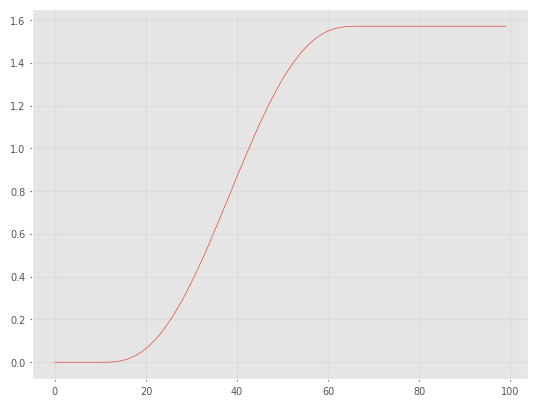

In [63]:
plt.plot(np.array(angle_history)[:, 0])